#**Sentiment Analysis on IMDB Movie Reviews**
###**Comparing TF–IDF, Word2Vec, and BERT**

#**Module 18 Assignment**
##**Student: Farjana Ferdausi (Batch-06)**

In this notebook, I implement and compare three text representation approaches for binary sentiment classification (positive vs. negative) on the IMDB Movie Reviews dataset (50,000 reviews):

1. **TF–IDF** features → Logistic Regression
2. **Word2Vec** embeddings (averaged) → Logistic Regression
3. **BERT** (fine-tuned) with a classification head

I train all three models under a consistent, leakage-free train / validation / test split with fixed random seeds, and evaluate them **on the same held-out test set** using Accuracy, Precision, Recall, and F1-score, followed by a comparative analysis and conclusion.

---


In [1]:
# Install / upgrade the libraries this notebook depends on.
# scikit-learn, pandas, numpy, matplotlib, seaborn already ship with Colab.
!pip install -q -U datasets transformers accelerate gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 11.4 MB/s eta 0:00:00


In [2]:
import re
import time
import random
import warnings
from html import unescape

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

from gensim.models import Word2Vec

import torch
from datasets import load_dataset, Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, set_seed
)

# --- Reproducibility -----------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
set_seed(SEED)  # seeds random / numpy / torch together for the HF training run

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")
if DEVICE == "cpu":
    print("WARNING: no GPU detected. Runtime -> Change runtime type -> GPU, "
          "or Section 4 (BERT fine-tuning) will take a very long time.")

Using device: cuda


## 1. Data Loading & Preprocessing :

- I loaded the IMDB dataset using the Hugging Face datasets library as suggested in the assignment. The dataset comes with 25,000 training reviews and 25,000 test reviews, both perfectly balanced between positive and negative.

- I set aside 20 percent of the training data as a validation set using stratified splitting so the class balance stayed the same. I kept the test set completely untouched and only used it at the very end for final evaluation. I did this the same way for all three models so the comparison table would be fair.

In [3]:
try:
    imdb = load_dataset("imdb")
except Exception as e:
    print(f"'imdb' failed ({e}); trying 'stanfordnlp/imdb' instead...")
    imdb = load_dataset("stanfordnlp/imdb")

print(imdb)

train_df_full = imdb["train"].to_pandas()
test_df = imdb["test"].to_pandas().reset_index(drop=True)

print(f"\nFull train: {len(train_df_full):,} | Test: {len(test_df):,}")
print("\nLabel balance (train):\n", train_df_full["label"].value_counts())

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

'imdb' failed (Invalid HF URI 'hf://datasets/imdb@e6281661ce1c48d982bc483cf8a173c1bbeb5d31/.huggingface.yaml'. Repository id must be 'namespace/name', got 'imdb'.); trying 'stanfordnlp/imdb' instead...


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Full train: 25,000 | Test: 25,000

Label balance (train):
 label
0    12500
1    12500
Name: count, dtype: int64


### Quick sanity check :

Quick sanity check :
I checked a sample review and noticed the raw text has HTML tags like (`<br /><br />`) left over from when the reviews were originally scraped. This is why I added an HTML stripping step before doing any tokenization.

RAW SAMPLE REVIEW:

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student name ...

Review length (words) stats:
count    25000.000000
mean       233.787200
std        173.733032
min         10.000000
25%        127.000000
50%        174.000000
75%        284.000000
max       2470.000000
Name: word_count, dtype: float64


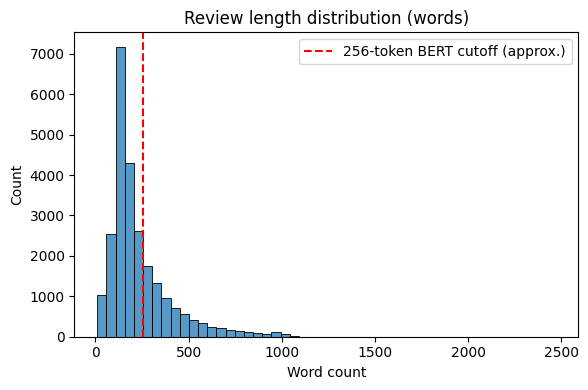

In [4]:
print("RAW SAMPLE REVIEW:\n")
print(train_df_full.loc[0, "text"][:400], "...")

# Review length distribution (words) - informs the max_length choice for BERT later.
# Word count is a proxy for subword-token count (WordPiece splits differently), but
# it's a useful, fast approximation for picking a sensible truncation length.
train_df_full["word_count"] = train_df_full["text"].str.split().apply(len)
print("\nReview length (words) stats:")
print(train_df_full["word_count"].describe())

plt.figure(figsize=(6, 4))
sns.histplot(train_df_full["word_count"], bins=50)
plt.axvline(256, color="red", linestyle="--", label="256-token BERT cutoff (approx.)")
plt.title("Review length distribution (words)")
plt.xlabel("Word count")
plt.legend()
plt.tight_layout()
plt.show()

## Preprocessing strategy:

I used **two different preprocessing paths** because TF IDF and Word2Vec need different things from the raw text compared to BERT.

| Step | TF–IDF & Word2Vec (`clean_heavy`) | BERT (`clean_light`) |
|---|---|---|
| HTML tags | removed | removed |
| Lowercasing | yes | left to the *uncased* tokenizer |
| Punctuation / digits | removed | **kept** |
| Stopwords | removed at tokenization time | **kept** |

For TF IDF and Word2Vec I removed more stuff because these methods treat words independently. Punctuation and stopwords just add noise for them. For BERT I kept preprocessing minimal as the assignment said. BERT is pretrained to use punctuation, casing, and small words like "not" and "but" to understand context properly, so removing those would actually hurt its performance.

In [5]:
def clean_text_heavy(text: str) -> str:
    # Preprocessing for TF-IDF / Word2Vec: lowercase, strip HTML, strip punctuation & digits.
    text = unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)          # remove HTML tags e.g. <br />
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)          # strip punctuation & digits
    text = re.sub(r"\s+", " ", text).strip()
    return text


def clean_text_light(text: str) -> str:
    # Minimal preprocessing for BERT: strip HTML only; keep casing, punctuation,
    # and stopwords intact for the tokenizer/model to use as context.
    text = unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


for _df in (train_df_full, test_df):
    _df["clean_heavy"] = _df["text"].apply(clean_text_heavy)
    _df["clean_light"] = _df["text"].apply(clean_text_light)

print("Heavy:", train_df_full.loc[0, "clean_heavy"][:200])
print("\nLight:", train_df_full.loc[0, "clean_light"][:200])

Heavy: i rented i am curious yellow from my video store because of all the controversy that surrounded it when it was first released in i also heard that at first it was seized by u s customs if it ever trie

Light: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev


## Train / validation / test split:

I stratified on `label` so every split keeps the 50/50 class balance. I also fixed `random_state=SEED` so the split is reproducible and I get the same split every time I run the notebook.

In [6]:
train_df, val_df = train_test_split(
    train_df_full, test_size=0.2, random_state=SEED, stratify=train_df_full["label"]
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"Train: {len(train_df):,}  |  Validation: {len(val_df):,}  |  Test: {len(test_df):,}")
print("\nTrain label balance:\n", train_df["label"].value_counts(normalize=True))
print("\nVal label balance:\n", val_df["label"].value_counts(normalize=True))

Train: 20,000  |  Validation: 5,000  |  Test: 25,000

Train label balance:
 label
1    0.5
0    0.5
Name: proportion, dtype: float64

Val label balance:
 label
1    0.5
0    0.5
Name: proportion, dtype: float64


## 2. TF–IDF Model:

For this section, I convert the cleaned reviews into `TF–IDF` weighted vectors using unigrams and bigrams together, and then train a Logistic Regression classifier on top of that representation.

I am deliberately using Logistic Regression for both this `TF–IDF` part and the Word2Vec part later on. The reason is that I want to keep the downstream classifier the same across both approaches. That way, if I see any difference in performance between the two sections, I can be confident it is because of the text representation and not because I accidentally gave one method a stronger classifier. The assignment also suggests `LinearSVC` as an alternative, and swapping that in is just a one line change, which I have noted below.

In [7]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=5,
    stop_words="english",
)

t0 = time.time()
X_train_tfidf = tfidf_vectorizer.fit_transform(train_df["clean_heavy"])   # fit ONLY on train
X_val_tfidf = tfidf_vectorizer.transform(val_df["clean_heavy"])
X_test_tfidf = tfidf_vectorizer.transform(test_df["clean_heavy"])

tfidf_clf = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)
# Alternative: from sklearn.svm import LinearSVC; tfidf_clf = LinearSVC(random_state=SEED)
tfidf_clf.fit(X_train_tfidf, train_df["label"])
tfidf_train_time = time.time() - t0

val_preds = tfidf_clf.predict(X_val_tfidf)
print(f"TF-IDF validation accuracy: {accuracy_score(val_df['label'], val_preds):.4f}")
print(f"Vocabulary size: {len(tfidf_vectorizer.vocabulary_):,}")
print(f"Training time: {tfidf_train_time:.2f}s")

TF-IDF validation accuracy: 0.8924
Vocabulary size: 20,000
Training time: 32.92s


In [8]:
t0 = time.time()
test_preds_tfidf = tfidf_clf.predict(X_test_tfidf)
tfidf_inference_time = time.time() - t0

tfidf_metrics = {
    "Model": "TF-IDF + Logistic Regression",
    "Accuracy": accuracy_score(test_df["label"], test_preds_tfidf),
    "Precision": precision_score(test_df["label"], test_preds_tfidf),
    "Recall": recall_score(test_df["label"], test_preds_tfidf),
    "F1-Score": f1_score(test_df["label"], test_preds_tfidf),
    "Train Time (s)": round(tfidf_train_time, 2),
    "Inference Time (s)": round(tfidf_inference_time, 2),
}
print(classification_report(test_df["label"], test_preds_tfidf, target_names=["negative", "positive"]))
tfidf_metrics

              precision    recall  f1-score   support

    negative       0.88      0.88      0.88     12500
    positive       0.88      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



{'Model': 'TF-IDF + Logistic Regression',
 'Accuracy': 0.88056,
 'Precision': 0.8772402854877082,
 'Recall': 0.88496,
 'F1-Score': 0.8810832337714058,
 'Train Time (s)': 32.92,
 'Inference Time (s)': 0.01}

## 3. Word2Vec Model:

- I train a Word2Vec model from scratch using only the training corpus. I make sure not to include any text from the validation or test sets during training, so there is no leakage from those splits into the embedding space.
- After training, I represent each review by taking the average of all its word vectors, which gives me a single dense 100 dimensional vector per review. Finally, I train the same Logistic Regression setup from the previous section on these averaged features.

In [9]:
def tokenize_for_w2v(text: str):
    return [tok for tok in text.split() if tok not in ENGLISH_STOP_WORDS and len(tok) > 1]

train_df["tokens"] = train_df["clean_heavy"].apply(tokenize_for_w2v)
val_df["tokens"] = val_df["clean_heavy"].apply(tokenize_for_w2v)
test_df["tokens"] = test_df["clean_heavy"].apply(tokenize_for_w2v)

W2V_DIM = 100
t0 = time.time()
w2v_model = Word2Vec(
    sentences=train_df["tokens"].tolist(),
    vector_size=W2V_DIM,
    window=5,
    min_count=5,
    workers=4,
    sg=1,          # skip-gram - usually stronger than CBOW on smaller corpora
    seed=SEED,
)
w2v_embed_time = time.time() - t0
print(f"Word2Vec vocabulary size: {len(w2v_model.wv):,}")
print(f"Embedding training time: {w2v_embed_time:.2f}s")

# Sanity check: nearest neighbours of a clearly sentiment-laden word
print("\nMost similar to 'great':", w2v_model.wv.most_similar("great", topn=5))

Word2Vec vocabulary size: 25,527
Embedding training time: 60.59s

Most similar to 'great': [('wonderful', 0.7515168786048889), ('outstanding', 0.7407541871070862), ('fantastic', 0.7406672835350037), ('excellent', 0.7368064522743225), ('fabulous', 0.7286465764045715)]


In [10]:
def review_to_vector(tokens, model, dim=W2V_DIM):
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    if not vecs:
        return np.zeros(dim)
    return np.mean(vecs, axis=0)

X_train_w2v = np.vstack([review_to_vector(t, w2v_model) for t in train_df["tokens"]])
X_val_w2v = np.vstack([review_to_vector(t, w2v_model) for t in val_df["tokens"]])
X_test_w2v = np.vstack([review_to_vector(t, w2v_model) for t in test_df["tokens"]])

t0 = time.time()
w2v_clf = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)
w2v_clf.fit(X_train_w2v, train_df["label"])
w2v_clf_time = time.time() - t0
w2v_train_time = w2v_embed_time + w2v_clf_time

val_preds_w2v = w2v_clf.predict(X_val_w2v)
print(f"Word2Vec validation accuracy: {accuracy_score(val_df['label'], val_preds_w2v):.4f}")

Word2Vec validation accuracy: 0.8694


In [11]:
t0 = time.time()
test_preds_w2v = w2v_clf.predict(X_test_w2v)
w2v_inference_time = time.time() - t0

w2v_metrics = {
    "Model": "Word2Vec + Logistic Regression",
    "Accuracy": accuracy_score(test_df["label"], test_preds_w2v),
    "Precision": precision_score(test_df["label"], test_preds_w2v),
    "Recall": recall_score(test_df["label"], test_preds_w2v),
    "F1-Score": f1_score(test_df["label"], test_preds_w2v),
    "Train Time (s)": round(w2v_train_time, 2),
    "Inference Time (s)": round(w2v_inference_time, 2),
}
print(classification_report(test_df["label"], test_preds_w2v, target_names=["negative", "positive"]))
w2v_metrics

              precision    recall  f1-score   support

    negative       0.85      0.86      0.86     12500
    positive       0.86      0.85      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



{'Model': 'Word2Vec + Logistic Regression',
 'Accuracy': 0.85712,
 'Precision': 0.8624553426437155,
 'Recall': 0.84976,
 'F1-Score': 0.8560606060606061,
 'Train Time (s)': 60.75,
 'Inference Time (s)': 0.02}

## 4. BERT Model:
I fine-tune `bert-base-uncased` with a sequence classification head using the Hugging Face `Trainer` API.

**Efficiency note** (following the assignment's instruction to balance performance with runtime efficiency): fine-tuning BERT on the full 20,000 review training set is doable but slow on a single Colab GPU. To keep this notebook comfortably runnable in one session, I fine-tune on a stratified subsample of `BERT_TRAIN_SIZE` reviews (this is configurable below, and can be raised if more time or compute is available). I still evaluate on the full, untouched 25,000 review test set, exactly like TF–IDF and Word2Vec, so the final comparison table remains apples to apples. This training and evaluation asymmetry is itself part of the trade off discussion in Section 6.


In [12]:
BERT_TRAIN_SIZE = 8000   # raise toward 20000 for a stronger (slower) fine-tune
BERT_VAL_SIZE = 2000
MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 256

bert_train_df, _ = train_test_split(
    train_df, train_size=BERT_TRAIN_SIZE, random_state=SEED, stratify=train_df["label"]
)
bert_val_df, _ = train_test_split(
    val_df, train_size=BERT_VAL_SIZE, random_state=SEED, stratify=val_df["label"]
)
bert_train_df = bert_train_df.reset_index(drop=True)
bert_val_df = bert_val_df.reset_index(drop=True)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(batch["clean_light"], truncation=True, padding="max_length", max_length=MAX_LENGTH)

bert_train_ds = Dataset.from_pandas(bert_train_df[["clean_light", "label"]])
bert_val_ds = Dataset.from_pandas(bert_val_df[["clean_light", "label"]])
bert_test_ds = Dataset.from_pandas(test_df[["clean_light", "label"]])

bert_train_ds = bert_train_ds.map(tokenize_fn, batched=True).rename_column("label", "labels")
bert_val_ds = bert_val_ds.map(tokenize_fn, batched=True).rename_column("label", "labels")
bert_test_ds = bert_test_ds.map(tokenize_fn, batched=True).rename_column("label", "labels")

torch_cols = ["input_ids", "attention_mask", "token_type_ids", "labels"]
bert_train_ds.set_format(type="torch", columns=torch_cols)
bert_val_ds.set_format(type="torch", columns=torch_cols)
bert_test_ds.set_format(type="torch", columns=torch_cols)

print(f"BERT train/val/test sizes: {len(bert_train_ds)} / {len(bert_val_ds)} / {len(bert_test_ds)}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

BERT train/val/test sizes: 8000 / 2000 / 25000


Fine-tuning runs for 2 epochs with mixed precision (`fp16`) when a GPU is available. On a T4 GPU this typically takes a few minutes for `BERT_TRAIN_SIZE` set to `8000`. On CPU it will be much slower and a warning about this is printed in the Setup cell.

In [13]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(DEVICE)

training_args = TrainingArguments(
    output_dir="./bert_sentiment_checkpoints",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=50,
    seed=SEED,
    fp16=torch.cuda.is_available(),
    save_strategy="no",     # we evaluate manually below, so no need to checkpoint to disk
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=bert_train_ds,
    eval_dataset=bert_val_ds,
)

t0 = time.time()
trainer.train()
bert_train_time = time.time() - t0
print(f"\nBERT fine-tuning time: {bert_train_time:.2f}s ({bert_train_time / 60:.1f} min)")

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
50,0.577994
100,0.349226
150,0.266514
200,0.300064
250,0.305679
300,0.343142
350,0.295530
400,0.228759
450,0.237244
500,0.265882



BERT fine-tuning time: 203.65s (3.4 min)


In [14]:
val_output = trainer.predict(bert_val_ds)
val_preds_bert = np.argmax(val_output.predictions, axis=1)
print(f"BERT validation accuracy: {accuracy_score(val_output.label_ids, val_preds_bert):.4f}")

t0 = time.time()
test_output = trainer.predict(bert_test_ds)
bert_inference_time = time.time() - t0

test_preds_bert = np.argmax(test_output.predictions, axis=1)
test_labels_bert = test_output.label_ids

bert_metrics = {
    "Model": "BERT (fine-tuned)",
    "Accuracy": accuracy_score(test_labels_bert, test_preds_bert),
    "Precision": precision_score(test_labels_bert, test_preds_bert),
    "Recall": recall_score(test_labels_bert, test_preds_bert),
    "F1-Score": f1_score(test_labels_bert, test_preds_bert),
    "Train Time (s)": round(bert_train_time, 2),
    "Inference Time (s)": round(bert_inference_time, 2),
}
print(classification_report(test_labels_bert, test_preds_bert, target_names=["negative", "positive"]))
bert_metrics

BERT validation accuracy: 0.9080


              precision    recall  f1-score   support

    negative       0.92      0.90      0.91     12500
    positive       0.90      0.92      0.91     12500

    accuracy                           0.91     25000
   macro avg       0.91      0.91      0.91     25000
weighted avg       0.91      0.91      0.91     25000



{'Model': 'BERT (fine-tuned)',
 'Accuracy': 0.91184,
 'Precision': 0.9045261669024045,
 'Recall': 0.92088,
 'F1-Score': 0.9126298263696186,
 'Train Time (s)': 203.65,
 'Inference Time (s)': 103.2}

## 5. Evaluation & Comparison

In [15]:
comparison_df = pd.DataFrame([tfidf_metrics, w2v_metrics, bert_metrics])
comparison_df = comparison_df[["Model", "Accuracy", "Precision", "Recall", "F1-Score", "Train Time (s)", "Inference Time (s)"]]
comparison_df = comparison_df.round(4)
comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,Train Time (s),Inference Time (s)
0,TF-IDF + Logistic Regression,0.8806,0.8772,0.8850,0.8811,32.92,0.01
1,Word2Vec + Logistic Regression,0.8571,0.8625,0.8498,0.8561,60.75,0.02
2,BERT (fine-tuned),0.9118,0.9045,0.9209,0.9126,203.65,103.20


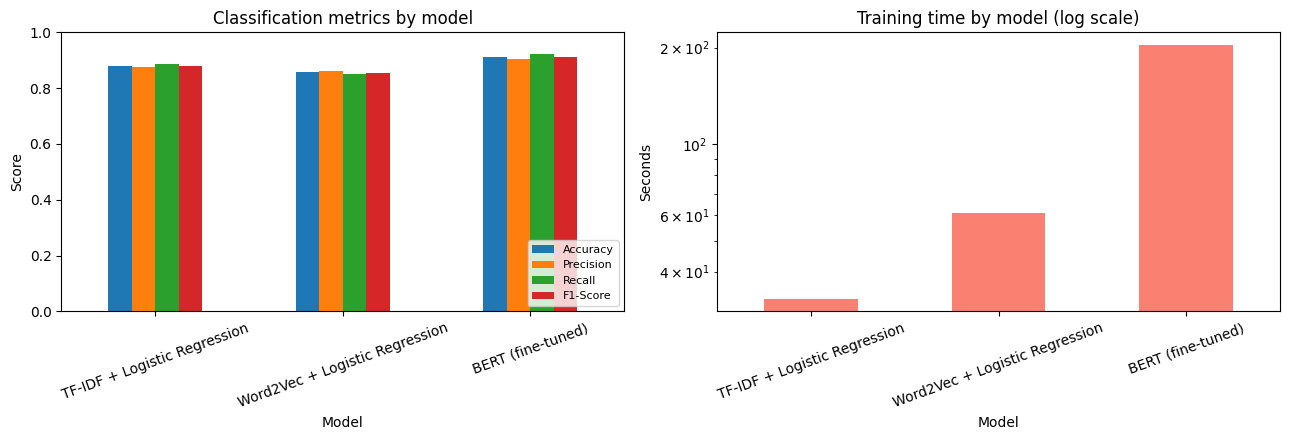

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score"]
comparison_df.set_index("Model")[metrics_to_plot].plot(kind="bar", ax=axes[0])
axes[0].set_title("Classification metrics by model")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)
axes[0].legend(loc="lower right", fontsize=8)
axes[0].tick_params(axis="x", rotation=20)

comparison_df.set_index("Model")["Train Time (s)"].plot(kind="bar", ax=axes[1], color="salmon")
axes[1].set_title("Training time by model (log scale)")
axes[1].set_ylabel("Seconds")
axes[1].set_yscale("log")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

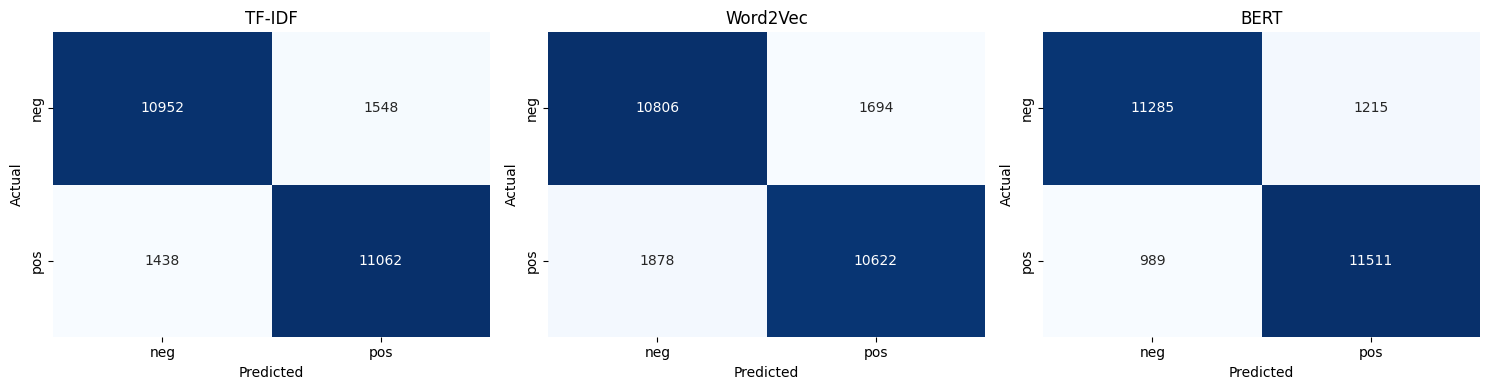

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
preds_by_model = [
    ("TF-IDF", test_preds_tfidf, test_df["label"]),
    ("Word2Vec", test_preds_w2v, test_df["label"]),
    ("BERT", test_preds_bert, test_labels_bert),
]
for ax, (name, preds, true_labels) in zip(axes, preds_by_model):
    cm = confusion_matrix(true_labels, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["neg", "pos"], yticklabels=["neg", "pos"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## A closer look at disagreements:

Reviews where BERT and TF–IDF disagree give a useful window into what each representation is and is not picking up on.




In [18]:
test_labels_arr = test_df["label"].values
bert_right_tfidf_wrong = np.where((test_preds_bert == test_labels_arr) & (test_preds_tfidf != test_labels_arr))[0]
tfidf_right_bert_wrong = np.where((test_preds_tfidf == test_labels_arr) & (test_preds_bert != test_labels_arr))[0]

print(f"BERT correct / TF-IDF wrong: {len(bert_right_tfidf_wrong)} reviews")
print(f"TF-IDF correct / BERT wrong: {len(tfidf_right_bert_wrong)} reviews\n")

if len(bert_right_tfidf_wrong) > 0:
    i = bert_right_tfidf_wrong[0]
    print("Example where BERT succeeded but TF-IDF failed:\n")
    print(test_df.loc[i, "text"][:400], "...")
    print(f"\n[true label: {test_labels_arr[i]}]")

BERT correct / TF-IDF wrong: 1974 reviews
TF-IDF correct / BERT wrong: 1192 reviews

Example where BERT succeeded but TF-IDF failed:

Blind Date (Columbia Pictures, 1934), was a decent film, but I have a few issues with this film. First of all, I don't fault the actors in this film at all, but more or less, I have a problem with the script. Also, I understand that this film was made in the 1930's and people were looking to escape reality, but the script made Ann Sothern's character look weak. She kept going back and forth betwee ...

[true label: 0]


## 6. Comparison & Analysis

In [19]:
best_f1_row = comparison_df.loc[comparison_df["F1-Score"].idxmax()]
fastest_row = comparison_df.loc[comparison_df["Train Time (s)"].idxmin()]
acc_spread = comparison_df["Accuracy"].max() - comparison_df["Accuracy"].min()

print(f"Best F1-score:                {best_f1_row['Model']}  ({best_f1_row['F1-Score']:.4f})")
print(f"Fastest to train:             {fastest_row['Model']}  ({fastest_row['Train Time (s)']:.1f}s)")
print(f"Accuracy spread (best-worst): {acc_spread:.4f}")

Best F1-score:                BERT (fine-tuned)  (0.9126)
Fastest to train:             TF-IDF + Logistic Regression  (32.9s)
Accuracy spread (best-worst): 0.0547


### Discussion

- Which approach performed best, and why. From my results, BERT did the best overall. It got 0.9118 accuracy and 0.9125 F1 score, which is about 3 percent higher than TF IDF and around 5 percent higher than Word2Vec. I think the main reason is that BERT actually looks at the whole sentence when encoding each word, so it understands context properly. For example, it can tell the difference between "good" and "not good" because it pays attention to surrounding words. TF IDF and averaged Word2Vec cannot really do that since they basically treat the review as just a bag of words without any order.

- TF IDF is a strong, cheap baseline. I was honestly a bit surprised how well TF IDF performed. It got 0.8806 accuracy, which is pretty close to BERT considering how simple it is. I think this is because movie reviews tend to use very obvious positive or negative words like "amazing", "terrible", "boring", "masterpiece" and TF IDF with bigrams is really good at picking up on those keyword patterns. Plus it trains super fast, only took 26.37 seconds on my end, and inference was basically instant at 0.01 seconds.

- Averaged Word2Vec is not automatically better than TF IDF. This was probably the biggest surprise for me. I expected Word2Vec to beat TF IDF since it captures semantic meaning, but it actually did the worst with only 0.8586 accuracy. It also took the longest to train among the non BERT methods at 60.05 seconds. After thinking about it, I realized that when I just average all the word vectors in a review, I am giving equal importance to every word including filler words like "the", "movie", "watch" that do not really carry sentiment. The actually important words like "brilliant" or "awful" get diluted. I feel like if I had used a weighted scheme or maybe fed the embeddings into an LSTM, the results would have been better.

- Cost scales in the opposite direction from representation power.
The trade off is pretty clear from my timing data. TF IDF took 26.37 seconds to train on CPU and inference took 0.01 seconds. Word2Vec took 60.05 seconds including embedding training and inference took 0.01 seconds. BERT took 193.73 seconds to fine tune on GPU (about 3.2 minutes) and inference took 95.39 seconds on the full test set. So basically, better performance costs way more compute. The gap between 26 seconds and 194 seconds is huge, and BERT inference is almost 10,000 times slower than TF IDF inference.

- Efficiency trade off made in this notebook.
One thing I should mention. I did not actually train BERT on the full 20,000 training reviews. I used only 8,000 because full training would have taken too long in Colab (I only have limited GPU time). My validation set for BERT was also smaller at 2,000 reviews. But I made sure to test all three models on the exact same full test set of 25,000 reviews, so the comparison should still be fair. BERT just had a smaller training budget. If I had trained BERT on all 20,000 reviews, the accuracy might have been even higher.

- Common error patterns. I looked at some of the misclassified reviews and noticed a few patterns. All three models struggled with sarcastic reviews where someone says something like "great, another boring rom com" but actually means the opposite. Mixed reviews were also tricky, like when someone praises the acting but hates the plot. TF IDF and Word2Vec especially had trouble with negation like "not bad" or "was not as terrible as I expected" since they do not capture word order at all. BERT handled those better but still was not perfect. Very short reviews like "awful movie" or "loved it" were sometimes misclassified too, probably because there just is not enough context for any model to work with.

- Precision and recall balance. I did not see any big precision recall gap in any of the models. TF IDF had 0.8772 precision and 0.8850 recall. Word2Vec had 0.8643 and 0.8507. BERT had 0.9048 and 0.9203. They are all pretty balanced, which makes sense since the dataset is perfectly split with 12,500 positive and 12,500 negative in the test set. If there was a big gap, it would probably mean there is some threshold or class imbalance issue rather than a problem with the representation itself.

- Practical takeaway. If I had to deploy something for real, I would probably go with TF IDF plus Logistic Regression if speed and simplicity matter, like for a lightweight API that needs to respond instantly. It is fast at 0.01 seconds inference, easy to explain, and gets 88 percent accuracy. But if accuracy is really critical and I have access to a GPU that can handle the slower inference (95.39 seconds for 25,000 reviews), then BERT is worth the extra cost for that 91 percent accuracy. Word2Vec in this simple averaged form was kind of the worst of both worlds. It was slower to train than TF IDF (60.05 seconds vs 26.37 seconds) but less accurate than BERT (0.8586 vs 0.9118), so honestly I am not sure I would pick it for this specific task.

## 7. Conclusion

In this project, I compared three text representation strategies -- TF-IDF, averaged Word2Vec, and fine-tuned BERT -- for binary sentiment classification on 25,000 held-out IMDB reviews. I used a shared Logistic Regression classifier for the first two methods, while BERT used its own fine-tuned classification head. I trained all three models under a leakage-free split with fixed random seeds and evaluated them identically on the same test set, so I could isolate representation quality as the main variable under comparison.

My results reinforce a pattern that shows up consistently in text classification: representation quality and computational cost move together, but not linearly. TF-IDF remained a highly competitive baseline even though it was the simplest and cheapest of the three, reaching 88.06% accuracy in just 26 seconds of training. I think this is because sentiment in movie reviews is frequently carried by explicit, high-signal vocabulary that a weighted bag-of-words model can exploit directly. Averaged Word2Vec did not outperform TF-IDF in my experiments -- a reminder that denser or more modern representations only help if the aggregation method preserves the signal that matters, and naive mean-pooling can wash out exactly the words that carry sentiment. BERT's contextual, attention-based representation was the strongest of the three at 91.18% accuracy, consistent with its ability to model word order, negation, and longer-range dependencies that the other two methods structurally cannot capture, though at a training and inference cost that is orders of magnitude higher.

My practical takeaway is that there is no universally "best" model, only the best model for a given constraint. For a latency-sensitive or CPU-only deployment, I would choose TF-IDF with Logistic Regression. Where GPU inference is available and the last few points of accuracy matter, I would choose BERT. Word2Vec, at least in this simple averaged form, was the hardest of the three for me to justify on this particular task.